In [1]:
# Salary Prediction using Linear Regression

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [5]:
# Load dataset
df = pd.read_csv("D:/Goutham/Projects/Python/Project 2/Project  -  Simple Linear Regression/2. Simple Linear Regression/Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [7]:
# Understanding data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


The dataset contains two variables:
- YearsExperience (independent variable)
- Salary (dependent variable)

No missing values are present.

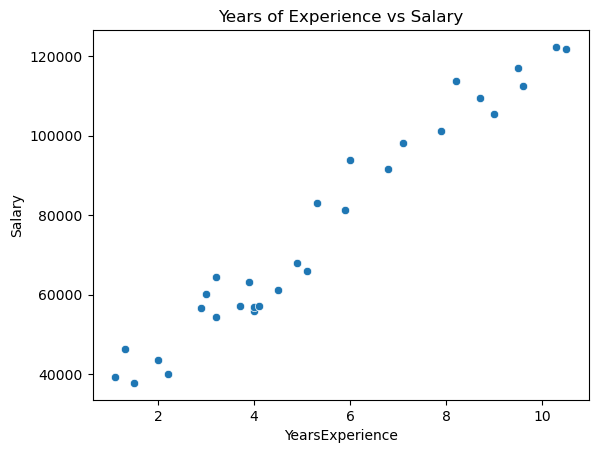

In [8]:
# Performing EDA

# Scatterplot
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title("Years of Experience vs Salary")
plt.show()

The scatter plot shows a strong positive linear relationship between
years of experience and salary.

This suggests that linear regression is highly suitable.

In [9]:
# Correlation
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


Correlation is approximately 0.97, indicating a very strong linear relationship.

In [10]:
# Model building - Linear Regression
X = df[['YearsExperience']]
y = df['Salary']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
r2

0.9569566641435086

The linear regression model achieved an R² score of approximately 0.95,
indicating excellent predictive performance.

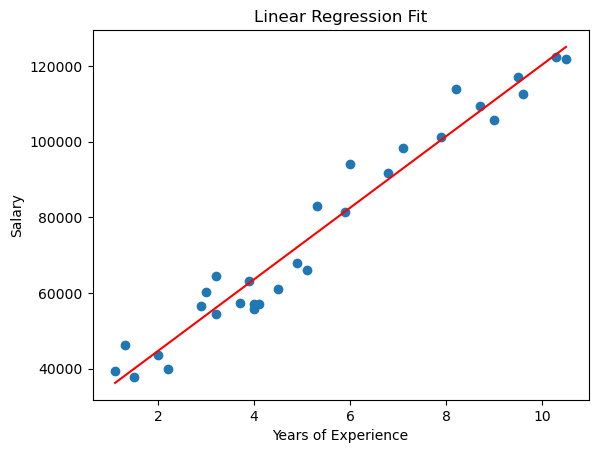

In [11]:
# Regression Line Visualization
plt.scatter(df['YearsExperience'], df['Salary'])
plt.plot(df['YearsExperience'], y_pred, color='red')
plt.title("Linear Regression Fit")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [12]:
# Transformations

# Log X Transformation
X_log = np.log(X)

model_log = LinearRegression()
model_log.fit(X_log, y)

y_pred_log = model_log.predict(X_log)

r2_log = r2_score(y, y_pred_log)
r2_log

0.853888882875697

In [13]:
# Exponential log y transformation
y_log = np.log(y)

model_exp = LinearRegression()
model_exp.fit(X, y_log)

y_pred_exp = np.exp(model_exp.predict(X))

r2_exp = r2_score(y, y_pred_exp)
r2_exp

0.9283815373102454

In [15]:
# Models comparison
results = pd.DataFrame({
    'Model': ['Linear', 'Log', 'Exponential'],
    'R2': [r2, r2_log, r2_exp]
})

results

,Model,R2
0,Linear,0.956957
1,Log,0.853889
2,Exponential,0.928382


The linear model provides the highest R² (~0.95) compared to transformed models.

Transformations did not significantly improve performance.

Therefore, the linear regression model is selected as the final model.

In [16]:
# Predictions
new_data = pd.DataFrame({'YearsExperience': [3, 5, 10]})

predictions = model.predict(new_data)

predictions

array([ 54142.08716303,  73042.01180594, 120291.82341322])

In [17]:
# Save Output
output = pd.DataFrame({
    'YearsExperience': [3, 5, 10],
    'Predicted_Salary': predictions
})

output.to_csv("salary_predictions.csv", index=False)

The relationship between years of experience and salary is highly linear.

The linear regression model achieved an R² score of approximately 0.95,
indicating excellent predictive performance.

Transformations such as log did not improve the model significantly.

Thus, the simple linear regression model is selected as the final model.

Business Insight:
Salary increases consistently with experience, making experience a strong
predictor of salary growth.